# AI Final Project - Project 2
## Adversarial Attacks and Defenses on CIFAR-10

This notebook implements white-box adversarial attacks and defense mechanisms on a ResNet20 model trained/evaluated on CIFAR-10.

In [198]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import random

In [199]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

In [200]:
RANDOM_SEED = 42
set_seed(RANDOM_SEED)

In [201]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [202]:
BATCH_SIZE = 128
NUM_WORKERS = 2

In [203]:
DATA_ROOT = "./data"

VAL_SIZE = 5000

PIN_MEMORY = torch.cuda.is_available()

In [204]:
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

raw_transform = transforms.Compose([
    transforms.ToTensor()
])

In [205]:
full_train_aug_dataset = torchvision.datasets.CIFAR10(
    root=DATA_ROOT,
    train=True,
    download=True,
    transform=train_transform
)

full_train_raw_dataset = torchvision.datasets.CIFAR10(
    root=DATA_ROOT,
    train=True,
    download=True,
    transform=raw_transform
)


test_dataset = torchvision.datasets.CIFAR10(
    root=DATA_ROOT,
    train=False,
    download=True,
    transform=raw_transform
)


CIFAR10_CLASSES = full_train_raw_dataset.classes

print("Classes:", CIFAR10_CLASSES)
print("Full train size:", len(full_train_raw_dataset))
print("Test size:", len(test_dataset))

Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Full train size: 50000
Test size: 10000


In [206]:
num_train = len(full_train_raw_dataset)
indices = torch.randperm(num_train, generator=torch.Generator().manual_seed(RANDOM_SEED))

val_indices = indices[:VAL_SIZE]
train_indices = indices[VAL_SIZE:]

In [207]:
train_dataset = torch.utils.data.Subset(full_train_aug_dataset, train_indices)
val_dataset = torch.utils.data.Subset(full_train_raw_dataset, val_indices)
mean_std_dataset = torch.utils.data.Subset(full_train_raw_dataset, train_indices)

In [208]:
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

In [209]:
mean_std_loader = torch.utils.data.DataLoader(
    mean_std_dataset,
    batch_size=512,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

In [210]:
# Sanity Check
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Min pixel value:", images.min().item())
print("Max pixel value:", images.max().item())
print("First labels:", labels[:10])

Images shape: torch.Size([128, 3, 32, 32])
Labels shape: torch.Size([128])
Min pixel value: 0.0
Max pixel value: 1.0
First labels: tensor([7, 4, 0, 1, 8, 1, 7, 6, 5, 5])


In [211]:
class Normalize(nn.Module):
    def __init__(self, mean, std):
        super().__init__()
        mean = torch.tensor(mean).view(1, 3, 1, 1)
        std = torch.tensor(std).view(1, 3, 1, 1)
        self.register_buffer("mean", mean)
        self.register_buffer("std", std)
        
    def forward(self, x):
        return (x - self.mean) / self.std

In [212]:
def compute_mean_std(loader):
    channels_sum = torch.zeros(3)
    channels_squared_sum = torch.zeros(3)
    num_pixels = 0
    
    for images, _ in loader:
        batch_size, channels, height, width = images.shape
        
        num_pixels += batch_size * height * width 
        
        channels_sum += images.sum(dim=[0, 2, 3])
        channels_squared_sum += (images ** 2).sum(dim=[0, 2, 3])
        
    mean = channels_sum / num_pixels 
    
    std = torch.sqrt(channels_squared_sum / num_pixels - mean ** 2)
    
    return mean, std

In [213]:
cifar10_mean, cifar10_std = compute_mean_std(mean_std_loader)

cifar10_mean = cifar10_mean.tolist()
cifar10_std = cifar10_std.tolist()

print("Mean:", cifar10_mean)
print("Std:", cifar10_std)

Mean: [0.4913501441478729, 0.4821614623069763, 0.44659730792045593]
Std: [0.24704869091510773, 0.24355383217334747, 0.26168447732925415]


In [214]:
class BasicBlock(nn.Module):
    expansion = 1
    
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        
        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)
        
        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        self.shortcut = nn.Sequential()
        
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),
                nn.BatchNorm2d(out_channels)
            )
            
    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)
        
        out = self.conv2(out)
        out = self.bn2(out)
        
        out = out + self.shortcut(x)
        out = F.relu(out)
        
        return out

In [215]:
class ResNet20(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        
        self.in_channels = 16
        
        self.conv1 = nn.Conv2d(
            3,
            16,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(16)
        
        self.layer1 = self._make_layer(
            out_channels=16,
            num_blocks=3,
            stride=1
        )
        
        self.layer2 = self._make_layer(
            out_channels=32,
            num_blocks=3,
            stride=2
        )
        
        self.layer3 = self._make_layer(
            out_channels=64,
            num_blocks=3,
            stride=2
        )
        
        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(64, num_classes)
        
        self._initialize_weights()
        
    def _make_layer(self, out_channels, num_blocks, stride):
        layers = []
        
        layers.append(
            BasicBlock(
                in_channels=self.in_channels,
                out_channels=out_channels,
                stride=stride
            )
        )
        
        self.in_channels = out_channels
        
        for _ in range(1, num_blocks):
            layers.append(
                BasicBlock(
                    in_channels=self.in_channels,
                    out_channels=out_channels,
                    stride=1
                )
            )
            
        return nn.Sequential(*layers)
    
    def _initialize_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Conv2d):
                nn.init.kaiming_normal_(
                    module.weight,
                    mode="fan_out",
                    nonlinearity="relu"
                )
            elif isinstance(module, nn.BatchNorm2d):
                nn.init.constant_(module.weight, 1)
                nn.init.constant_(module.bias, 0)
            elif isinstance(module, nn.Linear):
                nn.init.normal_(module.weight, mean=0.0, std=0.01)
                nn.init.constant_(module.bias, 0)
                
    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)
        
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        
        out = self.avg_pool(out)
        out = torch.flatten(out, 1)
        out = self.fc(out)
        
        return out

In [216]:
resnet20 = ResNet20(num_classes=10)

model = nn.Sequential(
    Normalize(cifar10_mean, cifar10_std),
    resnet20
).to(device)

model

Sequential(
  (0): Normalize()
  (1): ResNet20(
    (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (shortcut): Sequential()
      )
      (1): BasicBlock(
        (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (conv2): Conv2d(16, 16, kernel_size=

In [217]:
# Sanity Check
x_dummy = torch.rand(4, 3, 32, 32).to(device)

with torch.no_grad():
    logits = model(x_dummy)

print("Output shape:", logits.shape) # Should be [4, 10]

Output shape: torch.Size([4, 10])


In [218]:
EPOCHS = 30
LR = 0.1
MOMENTUM = 0.9
WEIGHT_DECAY = 5e-4

SAVE_PATH = "resnet20_cifar10_clean.pth"

In [219]:
saved_model_exists = False

In [220]:
if os.path.exists(SAVE_PATH):
    model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
    model = model.to(device)
    model.eval()
    
    saved_model_exists = True
    
    print(f"Loaded saved model from: {SAVE_PATH}")    
else:
    print("No saved model found. Training from scratch.")

Loaded saved model from: resnet20_cifar10_clean.pth


In [221]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        
        logits = model(images)
        loss = criterion(logits, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * labels.size(0)
        
        preds = logits.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)
    
    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples
    
    return avg_loss, avg_acc

In [222]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        
        
        logits = model(images)
        loss = criterion(logits, labels)
        
        total_loss += loss.item() * labels.size(0)
        
        preds = logits.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)
        
    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples
    
    return avg_loss, avg_acc

In [223]:
if not saved_model_exists:
    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=LR,
        momentum=MOMENTUM,
        weight_decay=WEIGHT_DECAY
    )

    scheduler = torch.optim.lr_scheduler.MultiStepLR(
        optimizer,
        milestones=[15, 25],
        gamma=0.1
    )

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    best_val_acc = 0.0

    for epoch in range(EPOCHS):
        start_time = time.time()

        train_loss, train_acc = train_one_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            criterion=criterion,
            device=device
        )

        val_loss, val_acc = evaluate(
            model=model,
            loader=val_loader,
            criterion=criterion,
            device=device
        )

        scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), SAVE_PATH)

        elapsed = time.time() - start_time

        print(
            f"Epoch [{epoch + 1:02d}/{EPOCHS}] "
            f"train_loss={train_loss:.4f} "
            f"train_acc={train_acc:.4f} "
            f"val_loss={val_loss:.4f} "
            f"val_acc={val_acc:.4f} "
            f"lr={scheduler.get_last_lr()[0]:.5f} "
            f"time={elapsed:.1f}s"
        )

    print("Best validation accuracy:", best_val_acc)
    print("Saved model:", SAVE_PATH)
else:
    print("Skipping training because saved model already exists.")

Skipping training because saved model already exists.


In [224]:
if not saved_model_exists:
    model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
    model = model.to(device)
    model.eval()
    print("Loaded best validation model.")

In [225]:
if not saved_model_exists:
    plt.figure(figsize=(7, 4))
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("ResNet20 Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

In [226]:
if not saved_model_exists:
    plt.figure(figsize=(7, 4))
    plt.plot(history["train_acc"], label="Train Accuracy")
    plt.plot(history["val_acc"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("ResNet20 Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

In [227]:
criterion = nn.CrossEntropyLoss()

val_loss, val_acc = evaluate(
    model=model,
    loader=val_loader,
    criterion=criterion,
    device=device
)

test_loss, test_acc = evaluate(
    model=model,
    loader=test_loader,
    criterion=criterion,
    device=device
)

print(f"Validation accuracy: {val_acc:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

Validation accuracy: 0.9024
Test accuracy: 0.8927


In [228]:
FGSM_EPSILONS = [0.0, 2 / 255, 4 / 255, 8 / 255, 16 / 255]

In [229]:
def fgsm_attack(model, images, labels, epsilon, criterion, device):
    model.eval()
    
    images = images.clone().detach().to(device)
    labels = labels.clone().detach().to(device)
    
    images.requires_grad = True
    
    logits = model(images)
    loss = criterion(logits, labels)
    
    model.zero_grad()
    loss.backward()
    
    grad_sign = images.grad.sign()
    
    adv_images = images + epsilon * grad_sign
    adv_images = torch.clamp(adv_images, 0.0, 1.0)
    
    return adv_images.detach()

In [230]:
# Sanity Check 
sanity_check_images, sanity_check_labels = next(iter(test_loader))

sanity_check_images = sanity_check_images.to(device)
sanity_check_labels = sanity_check_labels.to(device)

tolerance = 1e-6

for sanity_check_eps in FGSM_EPSILONS:

    sanity_check_adv_images = fgsm_attack(
        model,
        sanity_check_images,
        sanity_check_labels,
        sanity_check_eps,
        criterion,
        device
    )

    delta = sanity_check_adv_images - sanity_check_images

    assert delta.abs().max().item() <= sanity_check_eps + tolerance

In [231]:
def evaluate_fgsm(model, loader, epsilons, criterion, device):
    results = {}
    
    for epsilon in epsilons:
        total_correct = 0
        total_samples = 0
        
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            
            if epsilon == 0.0:
                adv_images = images 
            else:
                adv_images = fgsm_attack(
                    model,
                    images,
                    labels, 
                    epsilon,
                    criterion,
                    device
                )
                
            with torch.no_grad():
                logits = model(adv_images)
                preds = logits.argmax(dim=1)
                
            total_correct += (preds == labels).sum().item()
            total_samples += labels.size(0)
            
        accuracy = total_correct / total_samples
        results[epsilon] = accuracy
        
        print(f"epsilon={epsilon:.5f} | accuracy={accuracy:.4f}")
        
    return results

In [232]:
criterion = nn.CrossEntropyLoss()

fgsm_results = evaluate_fgsm(
    model,
    test_loader,
    FGSM_EPSILONS,
    criterion,
    device
)

epsilon=0.00000 | accuracy=0.8927
epsilon=0.00784 | accuracy=0.2148
epsilon=0.01569 | accuracy=0.1211
epsilon=0.03137 | accuracy=0.0856
epsilon=0.06275 | accuracy=0.0780


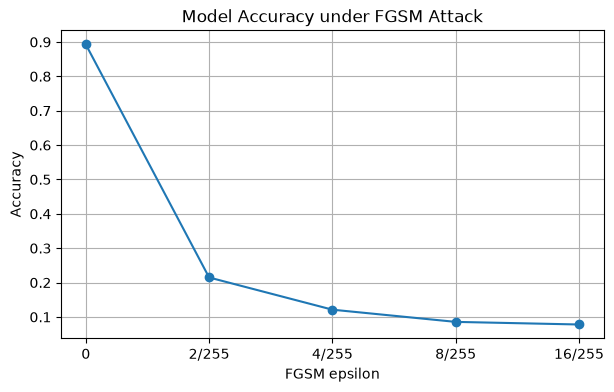

In [233]:
eps_labels = ["0", "2/255", "4/255", "8/255", "16/255"]
accuracies = [fgsm_results[eps] for eps in FGSM_EPSILONS]

plt.figure(figsize=(7, 4))
plt.plot(eps_labels, accuracies, marker="o")
plt.xlabel("FGSM epsilon")
plt.ylabel("Accuracy")
plt.title("Model Accuracy under FGSM Attack")
plt.grid(True)
plt.show()

In [234]:
def get_confidence_and_pred(model, image):
    model.eval()
    
    with torch.no_grad():
        logits = model(image.unsqueeze(0).to(device))
        probs = F.softmax(logits, dim=1)
        
        confidence, pred = probs.max(dim=1)
        
    return confidence.item(), pred.item()

In [235]:
def find_correct_sample(model, loader, device, idx=0):
    model.eval()
    
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        
        with torch.no_grad():
            logits = model(images)
            preds = logits.argmax(dim=1)
            
        correct_indices = (preds == labels).nonzero(as_tuple=True)[0]
        
        if len(correct_indices) > 0:
            if idx >= len(correct_indices):
                idx = 0  
                
            sample_idx = correct_indices[idx].item()
            return images[sample_idx].detach().cpu(), labels[sample_idx].detach().cpu()
        
    raise RuntimeError("No correctly classified sample found.")

In [236]:
def show_fgsm_examples(model, loader, epsilons, criterion, class_names, device, idx=0):
    clean_image, label = find_correct_sample(model, loader, device, idx)

    images_to_show = []
    titles = []

    true_label = label.item()

    for epsilon in epsilons:
        if epsilon == 0.0:
            display_image = clean_image.clone()
        else:
            adv_image = fgsm_attack(
                model=model,
                images=clean_image.unsqueeze(0),
                labels=label.unsqueeze(0),
                epsilon=epsilon,
                criterion=criterion,
                device=device
            )
            display_image = adv_image.squeeze(0).detach().cpu()

        confidence, pred = get_confidence_and_pred(model, display_image)

        images_to_show.append(display_image)

        if epsilon == 0.0:
            eps_text = "Clean"
        else:
            eps_text = f"eps={epsilon:.4f}"

        title = (
            f"{eps_text}\n"
            f"Pred: {class_names[pred]}\n"
            f"Conf: {confidence:.2f}"
        )

        titles.append(title)

    plt.figure(figsize=(15, 3))

    for i, image in enumerate(images_to_show):
        plt.subplot(1, len(images_to_show), i + 1)

        image_np = image.permute(1, 2, 0).numpy()
        image_np = np.clip(image_np, 0.0, 1.0)

        plt.imshow(image_np)
        plt.title(titles[i])
        plt.axis("off")

    plt.suptitle(f"True Label: {class_names[true_label]}", fontsize=14)
    plt.tight_layout()
    plt.show()

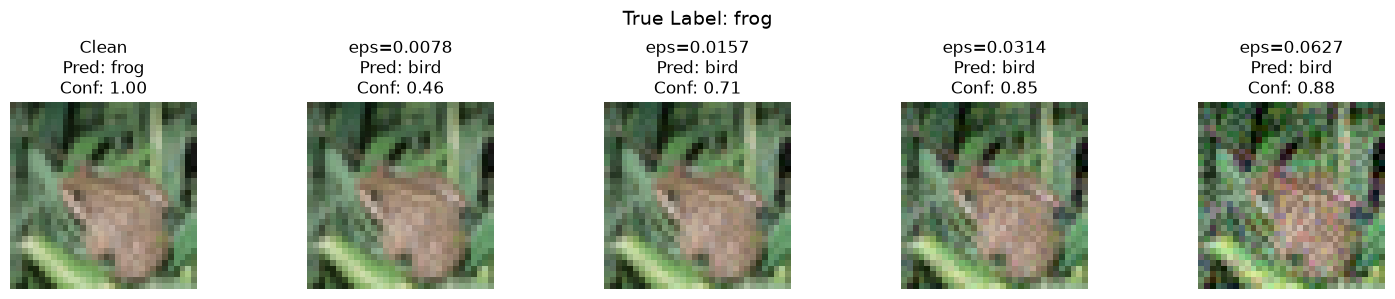

In [237]:
show_fgsm_examples(
    model=model,
    loader=test_loader,
    epsilons=FGSM_EPSILONS,
    criterion=criterion,
    class_names=CIFAR10_CLASSES,
    device=device,
    idx=4
)

In [238]:
def show_fgsm_example(
    model,
    loader,
    epsilon,
    criterion,
    class_names,
    device,
    idx=0
):
    clean_image, label = find_correct_sample(model, loader, device, idx)

    adv_image = fgsm_attack(
        model=model,
        images=clean_image.unsqueeze(0),
        labels=label.unsqueeze(0),
        epsilon=epsilon,
        criterion=criterion,
        device=device
    ).squeeze(0).detach().cpu()

    noise = adv_image - clean_image

    noise_for_display = noise / (2 * epsilon) + 0.5
    noise_for_display = torch.clamp(noise_for_display, 0.0, 1.0)

    clean_conf, clean_pred = get_confidence_and_pred(model, clean_image)
    adv_conf, adv_pred = get_confidence_and_pred(model, adv_image)

    l_inf = noise.abs().max().item()
    l2_norm = torch.norm(noise.flatten(), p=2).item()

    images_to_show = [
        clean_image,
        noise_for_display,
        adv_image
    ]

    titles = [
        f"Clean\nPred: {class_names[clean_pred]}\nConf: {clean_conf:.2f}",
        "FGSM Noise\nscaled for display",
        f"FGSM Adv\nPred: {class_names[adv_pred]}\nConf: {adv_conf:.2f}"
    ]

    plt.figure(figsize=(9, 3))

    for i, image in enumerate(images_to_show):
        plt.subplot(1, 3, i + 1)

        image_np = image.permute(1, 2, 0).numpy()
        image_np = np.clip(image_np, 0.0, 1.0)

        plt.imshow(image_np)
        plt.title(titles[i])
        plt.axis("off")

    plt.suptitle(
        f"True Label: {class_names[label.item()]} | "
        f"Epsilon: {epsilon:.5f} | "
        f"L∞: {l_inf:.5f} | "
        f"L2: {l2_norm:.4f}",
        fontsize=12
    )

    plt.tight_layout()
    plt.show()

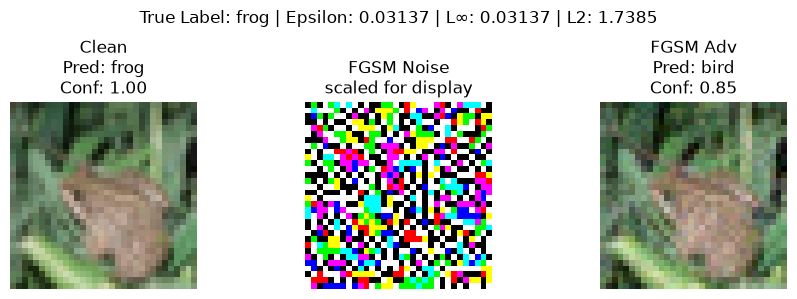

In [239]:
show_fgsm_example(
    model,
    test_loader,
    epsilon=8 / 255,
    criterion=criterion,
    class_names=CIFAR10_CLASSES,
    device=device,
    idx=4
)

In [240]:
PGD_EPSILON = 8 / 255
PGD_ALPHA = 2 / 255
PGD_STEPS = 20
PGD_RANDOM_START = True

In [241]:
def pgd_attack(model, images, labels, epsilon, alpha, num_steps, criterion, device, random_start=True):
    model.eval()
    
    images = images.clone().detach().to(device)
    labels = labels.clone().detach().to(device)
    
    if random_start:
        delta = torch.empty_like(images).uniform_(-epsilon, epsilon)
        adv_images = images + delta
        adv_images = torch.clamp(adv_images, 0.0, 1.0)
    else:
        adv_images = images.clone().detach()
        
    for _ in range(num_steps):
        adv_images.requires_grad = True
        
        logits = model(adv_images)
        loss = criterion(logits, labels)
        
        model.zero_grad()
        loss.backward()
        
        with torch.no_grad():
            grad_sign = adv_images.grad.sign()
            
            adv_images = adv_images + alpha * grad_sign
            
            delta = adv_images - images
            delta = torch.clamp(delta, -epsilon, epsilon)
            
            adv_images = images + delta
            adv_images = torch.clamp(adv_images, 0.0, 1.0)
            
        adv_images = adv_images.detach()
        
    return adv_images

In [242]:
# Sanity Check
sanity_check_images, sanity_check_labels = next(iter(test_loader))

sanity_check_images = sanity_check_images.to(device)
sanity_check_labels = sanity_check_labels.to(device)

sanity_check_adv_images = pgd_attack(
    model,
    sanity_check_images,
    sanity_check_labels,
    PGD_EPSILON,
    PGD_ALPHA,
    PGD_STEPS,
    criterion,
    device,
    random_start=PGD_RANDOM_START
)

delta = sanity_check_adv_images - sanity_check_images
max_delta = delta.abs().max().item()

print("Max |delta|:", max_delta)
print("Epsilon:", PGD_EPSILON)
print("Difference:", max_delta - PGD_EPSILON)
print("Adv min:", sanity_check_adv_images.min().item())
print("Adv max:", sanity_check_adv_images.max().item())

assert max_delta <= PGD_EPSILON + 1e-6
assert sanity_check_adv_images.min().item() >= 0.0
assert sanity_check_adv_images.max().item() <= 1.0

Max |delta|: 0.03137257695198059
Epsilon: 0.03137254901960784
Difference: 2.793237274811844e-08
Adv min: 0.0
Adv max: 1.0


In [243]:
def evaluate_pgd(model, loader, epsilon, alpha, num_steps, criterion, device, random_start=True):
    model.eval()
    
    total_correct = 0
    total_samples = 0
    
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        
        adv_images = pgd_attack(
            model,
            images,
            labels,
            epsilon,
            alpha,
            num_steps,
            criterion,
            device,
            random_start
        )
        
        with torch.no_grad():
            logits = model(adv_images)
            preds = logits.argmax(dim=1)
            
        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)
        
    accuracy = total_correct / total_samples
    
    print(
        f"PGD accuracy | "
        f"epsilon={epsilon:.5f}, "
        f"alpha={alpha:.5f}, "
        f"steps={num_steps}: "
        f"{accuracy:.4f}"
    )
    
    return accuracy

In [244]:
pgd_acc = evaluate_pgd(
    model,
    test_loader,
    PGD_EPSILON,
    PGD_ALPHA,
    PGD_STEPS,
    criterion,
    device,
    PGD_RANDOM_START
)

PGD accuracy | epsilon=0.03137, alpha=0.00784, steps=20: 0.0000


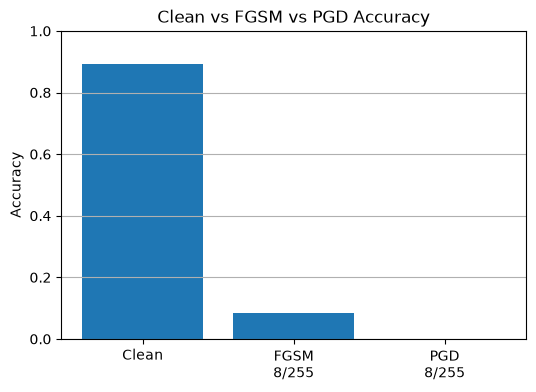

In [245]:
clean_acc = fgsm_results[0.0]
fgsm_acc_8_255 = fgsm_results[8 / 255]

attack_names = ["Clean", "FGSM\n8/255", "PGD\n8/255"]
attack_accuracies = [clean_acc, fgsm_acc_8_255, pgd_acc]

plt.figure(figsize=(6, 4))
plt.bar(attack_names, attack_accuracies)
plt.ylabel("Accuracy")
plt.title("Clean vs FGSM vs PGD Accuracy")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.show()

In [246]:
def show_pgd_example(
    model,
    loader,
    epsilon,
    alpha,
    num_steps,
    criterion,
    class_names,
    device,
    random_start=True,
    idx=0
):
    clean_image, label = find_correct_sample(model, loader, device, idx)

    adv_image = pgd_attack(
        model=model,
        images=clean_image.unsqueeze(0),
        labels=label.unsqueeze(0),
        epsilon=epsilon,
        alpha=alpha,
        num_steps=num_steps,
        criterion=criterion,
        device=device,
        random_start=random_start
    ).squeeze(0).detach().cpu()

    noise = adv_image - clean_image
    noise_for_display = noise / (2 * epsilon) + 0.5
    noise_for_display = torch.clamp(noise_for_display, 0.0, 1.0)

    clean_conf, clean_pred = get_confidence_and_pred(model, clean_image)
    adv_conf, adv_pred = get_confidence_and_pred(model, adv_image)

    images_to_show = [
        clean_image,
        noise_for_display,
        adv_image
    ]

    titles = [
        f"Clean\nPred: {class_names[clean_pred]}\nConf: {clean_conf:.2f}",
        "PGD Noise\nscaled for display",
        f"PGD Adv\nPred: {class_names[adv_pred]}\nConf: {adv_conf:.2f}"
    ]

    plt.figure(figsize=(9, 3))

    for i, image in enumerate(images_to_show):
        plt.subplot(1, 3, i + 1)

        image_np = image.permute(1, 2, 0).numpy()
        image_np = np.clip(image_np, 0.0, 1.0)

        plt.imshow(image_np)
        plt.title(titles[i])
        plt.axis("off")

    plt.suptitle(f"True Label: {class_names[label.item()]}", fontsize=14)
    plt.tight_layout()
    plt.show()

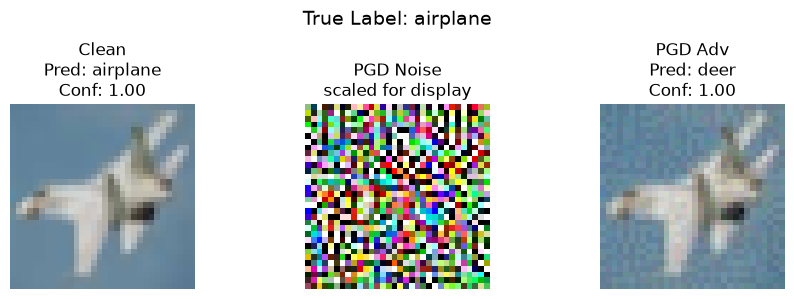

In [247]:
show_pgd_example(
    model,
    test_loader,
    PGD_EPSILON,
    PGD_ALPHA,
    PGD_STEPS,
    criterion,
    CIFAR10_CLASSES,
    device,
    PGD_RANDOM_START,
    idx=10
)

In [248]:
PGD_EPSILONS = [0.0, 2 / 255, 4 / 255, 8 / 255, 16 / 255]

In [249]:
def evaluate_pgd_multiple_eps(
    model,
    loader,
    epsilons,
    num_steps,
    criterion,
    device,
    random_start=True
):
    model.eval()
    
    results = {}
    
    for epsilon in epsilons:
        total_correct = 0
        total_samples = 0
        
        if epsilon == 0.0:
            alpha = 0
        else:
            alpha = epsilon / 4
            
        for images,labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            
            if epsilon == 0.0:
                adv_images = images
            else:
                adv_images = pgd_attack(
                    model,
                    images,
                    labels,
                    epsilon,
                    alpha,
                    num_steps,
                    criterion,
                    device,
                    random_start=random_start
                )
                
            with torch.no_grad():
                logits = model(adv_images)
                preds = logits.argmax(dim=1)
            
            total_correct += (preds == labels).sum().item()
            total_samples += labels.size(0)
            
        accuracy = total_correct / total_samples
        
        results[epsilon] = accuracy
        
    
        print(
            f"epsilon={epsilon:.5f} | "
            f"alpha={alpha:.5f} | "
            f"steps={num_steps} | "
            f"accuracy={accuracy:.4f}"
        )
        
    return results

In [250]:
pgd_results = evaluate_pgd_multiple_eps(
    model,
    test_loader,
    PGD_EPSILONS,
    PGD_STEPS,
    criterion,
    device,
    PGD_RANDOM_START
)

epsilon=0.00000 | alpha=0.00000 | steps=20 | accuracy=0.8927
epsilon=0.00784 | alpha=0.00196 | steps=20 | accuracy=0.0058
epsilon=0.01569 | alpha=0.00392 | steps=20 | accuracy=0.0000
epsilon=0.03137 | alpha=0.00784 | steps=20 | accuracy=0.0000
epsilon=0.06275 | alpha=0.01569 | steps=20 | accuracy=0.0000


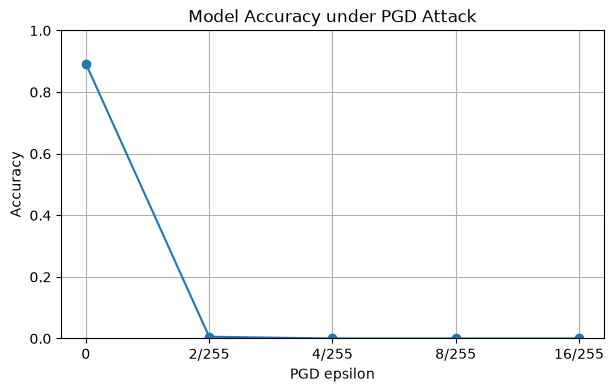

In [251]:
pgd_eps_labels = ["0", "2/255", "4/255", "8/255", "16/255"]
pgd_accuracies = [pgd_results[eps] for eps in PGD_EPSILONS]

plt.figure(figsize=(7, 4))
plt.plot(pgd_eps_labels, pgd_accuracies, marker="o")
plt.xlabel("PGD epsilon")
plt.ylabel("Accuracy")
plt.title("Model Accuracy under PGD Attack")
plt.grid(True)
plt.ylim(0, 1)
plt.show()

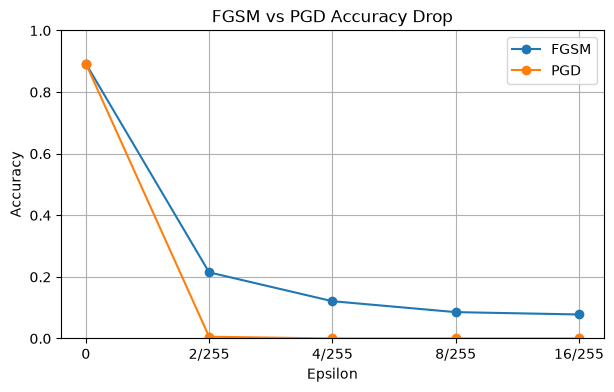

In [252]:
fgsm_accuracies = [fgsm_results[eps] for eps in PGD_EPSILONS]
pgd_accuracies = [pgd_results[eps] for eps in PGD_EPSILONS]

plt.figure(figsize=(7, 4))
plt.plot(pgd_eps_labels, fgsm_accuracies, marker="o", label="FGSM")
plt.plot(pgd_eps_labels, pgd_accuracies, marker="o", label="PGD")
plt.xlabel("Epsilon")
plt.ylabel("Accuracy")
plt.title("FGSM vs PGD Accuracy Drop")
plt.grid(True)
plt.ylim(0, 1)
plt.legend()
plt.show()

In [253]:
DEEPFOOL_MAX_ITER = 50
DEEPFOOL_NUM_CLASSES = 10
DEEPFOOL_OVERSHOOT = 0.02
DEEPFOOL_EVAL_SIZE = 500

In [254]:
def deepfool_attack_single_image(
    model,
    image,
    device,
    num_classes=10,
    max_iter=50,
    overshoot=0.02
):
    model.eval()

    image = image.clone().detach().to(device)

    with torch.no_grad():
        logits = model(image.unsqueeze(0))
        initial_pred = logits.argmax(dim=1).item()

    adv_image = image.clone().detach()
    perturbation = torch.zeros_like(image).to(device)

    final_pred = initial_pred
    num_iter = 0

    while final_pred == initial_pred and num_iter < max_iter:
        adv_image.requires_grad = True

        logits = model(adv_image.unsqueeze(0)).squeeze(0)

        sorted_classes = torch.argsort(logits, descending=True)
        sorted_classes = sorted_classes[:num_classes]

        current_class = initial_pred

        model.zero_grad()

        current_logit = logits[current_class]
        current_grad = torch.autograd.grad(
            current_logit,
            adv_image,
            retain_graph=True,
            create_graph=False
        )[0]

        min_distance = float("inf")
        best_perturbation = None

        for class_idx in sorted_classes:
            class_idx = class_idx.item()

            if class_idx == current_class:
                continue

            class_logit = logits[class_idx]

            class_grad = torch.autograd.grad(
                class_logit,
                adv_image,
                retain_graph=True,
                create_graph=False
            )[0]

            w_k = class_grad - current_grad
            f_k = class_logit - current_logit

            w_k_norm = torch.norm(w_k.flatten(), p=2)

            if w_k_norm.item() == 0:
                continue

            distance = torch.abs(f_k) / w_k_norm

            if distance.item() < min_distance:
                min_distance = distance.item()
                best_perturbation = (torch.abs(f_k) / (w_k_norm ** 2)) * w_k

        if best_perturbation is None:
            break

        perturbation = perturbation + best_perturbation.detach()

        adv_image = image + (1 + overshoot) * perturbation
        adv_image = torch.clamp(adv_image, 0.0, 1.0).detach()

        with torch.no_grad():
            final_logits = model(adv_image.unsqueeze(0))
            final_pred = final_logits.argmax(dim=1).item()

        num_iter += 1

    success = final_pred != initial_pred
    final_perturbation = adv_image - image

    return adv_image.detach(), final_perturbation.detach(), initial_pred, final_pred, num_iter, success

In [255]:
# Sanity Check

sample_images, sample_labels = next(iter(test_loader))

sample_image = sample_images[0].to(device)
sample_label = sample_labels[0].item()

adv_image, perturbation, initial_pred, final_pred, num_iter, success = deepfool_attack_single_image(
    model,
    sample_image,
    device,
    DEEPFOOL_NUM_CLASSES,
    DEEPFOOL_MAX_ITER,
    DEEPFOOL_OVERSHOOT
)

print("True label:", CIFAR10_CLASSES[sample_label])
print("Initial prediction:", CIFAR10_CLASSES[initial_pred])
print("Final prediction:", CIFAR10_CLASSES[final_pred])
print("Iterations:", num_iter)
print("Success:", success)
print("L2 perturbation:", torch.norm(perturbation.flatten(), p=2).item())
print("Adv min:", adv_image.min().item())
print("Adv max:", adv_image.max().item())

assert adv_image.min().item() >= 0.0
assert adv_image.max().item() <= 1.0

True label: cat
Initial prediction: cat
Final prediction: dog
Iterations: 1
Success: True
L2 perturbation: 0.08408287167549133
Adv min: 0.051014333963394165
Adv max: 0.9999100565910339


In [256]:
def evaluate_deepfool(
    model,
    loader,
    max_samples,
    num_classes,
    max_iter,
    overshoot,
    device
):
    model.eval()
    
    total_samples = 0
    clean_correct = 0
    adv_correct = 0
    
    attacked_samples = 0
    successful_attacks = 0
    l2_norm_successful = []
    
    for images, labels in loader:
        for i in range(images.size(0)):
            if total_samples >= max_samples:
                break
                
            image = images[i].to(device)
            label = labels[i].to(device)
            
            with torch.no_grad():
                clean_logits = model(image.unsqueeze(0))
                clean_pred = clean_logits.argmax(dim=1).item()
                
            total_samples += 1
            
            if clean_pred == label.item():
                clean_correct += 1
                
                adv_image, perturbation, initial_pred, final_pred, num_iter, success = deepfool_attack_single_image(
                    model,
                    image,
                    device,
                    num_classes,
                    max_iter,
                    overshoot
                )
                
                attacked_samples += 1
                
                with torch.no_grad():
                    adv_logits = model(adv_image.unsqueeze(0))
                    adv_pred = adv_logits.argmax(dim=1).item()
                    
                if adv_pred == label.item():
                    adv_correct += 1
                else: 
                    successful_attacks += 1
                    l2_norm = torch.norm(perturbation.flatten(), p=2).item()
                    l2_norm_successful.append(l2_norm)
                    
            if total_samples % 50 == 0:
                print(f"Processed {total_samples}/{max_samples} samples")
                
        if total_samples >= max_samples:
            break
            
    clean_accuracy = clean_correct / total_samples
    robust_accuracy = adv_correct / total_samples
    
    if attacked_samples > 0:
        success_rate = successful_attacks / attacked_samples
    else:
        success_rate = 0.0
        
    if len(l2_norm_successful) > 0:
        avg_l2_successful = float(np.mean(l2_norm_successful))
    else: 
        avg_l2_successful = 0.0
        
    results = {
        "total_samples": total_samples,
        "clean_correct": clean_correct,
        "clean_accuracy": clean_accuracy,
        "adv_correct": adv_correct,
        "robust_accuracy": robust_accuracy,
        "attacked_samples": attacked_samples,
        "successful_attacks": successful_attacks,
        "success_rate": success_rate,
        "avg_l2_successful": avg_l2_successful
    }

    print("\nDeepFool Results")
    print("----------------")
    print(f"Total samples: {total_samples}")
    print(f"Clean accuracy: {clean_accuracy:.4f}")
    print(f"Robust accuracy after DeepFool: {robust_accuracy:.4f}")
    print(f"Attacked initially correct samples: {attacked_samples}")
    print(f"Successful attacks: {successful_attacks}")
    print(f"Success rate on initially correct samples: {success_rate:.4f}")
    print(f"Average L2 norm on successful attacks: {avg_l2_successful:.6f}")

    return results             

In [257]:
deepfool_results = evaluate_deepfool(
    model,
    test_loader,
    max_samples=DEEPFOOL_EVAL_SIZE,
    num_classes=DEEPFOOL_NUM_CLASSES,
    max_iter=DEEPFOOL_MAX_ITER,
    overshoot=DEEPFOOL_OVERSHOOT,
    device=device
)

Processed 50/500 samples
Processed 100/500 samples
Processed 150/500 samples
Processed 200/500 samples
Processed 250/500 samples
Processed 300/500 samples
Processed 350/500 samples
Processed 400/500 samples
Processed 450/500 samples
Processed 500/500 samples

DeepFool Results
----------------
Total samples: 500
Clean accuracy: 0.9080
Robust accuracy after DeepFool: 0.0000
Attacked initially correct samples: 454
Successful attacks: 454
Success rate on initially correct samples: 1.0000
Average L2 norm on successful attacks: 0.108918


In [258]:
def show_deepfool_example(
    model,
    loader,
    num_classes,
    max_iter,
    overshoot,
    class_names,
    device,
    idx=0
):
    clean_image, label = find_correct_sample(model, loader, device, idx)

    adv_image, perturbation, initial_pred, final_pred, num_iter, success = deepfool_attack_single_image(
        model=model,
        image=clean_image,
        device=device,
        num_classes=num_classes,
        max_iter=max_iter,
        overshoot=overshoot
    )

    clean_image = clean_image.detach().cpu()
    adv_image = adv_image.detach().cpu()
    perturbation = perturbation.detach().cpu()

    l2_norm = torch.norm(perturbation.flatten(), p=2).item()

    max_abs_noise = perturbation.abs().max().item()

    if max_abs_noise > 0:
        noise_for_display = perturbation / (2 * max_abs_noise) + 0.5
    else:
        noise_for_display = perturbation + 0.5

    noise_for_display = torch.clamp(noise_for_display, 0.0, 1.0)

    images_to_show = [
        clean_image,
        noise_for_display,
        adv_image
    ]

    titles = [
        f"Clean\nPred: {class_names[initial_pred]}",
        f"DeepFool Noise\nL2: {l2_norm:.4f}",
        f"Adversarial\nPred: {class_names[final_pred]}"
    ]

    plt.figure(figsize=(9, 3))

    for i, image in enumerate(images_to_show):
        plt.subplot(1, 3, i + 1)

        image_np = image.permute(1, 2, 0).numpy()
        image_np = np.clip(image_np, 0.0, 1.0)

        plt.imshow(image_np)
        plt.title(titles[i])
        plt.axis("off")

    plt.suptitle(
        f"True Label: {class_names[label.item()]} | "
        f"Iterations: {num_iter} | "
        f"Success: {success}",
        fontsize=13
    )

    plt.tight_layout()
    plt.show()

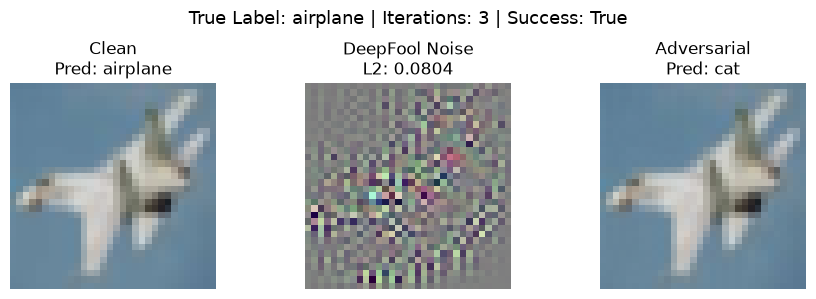

In [259]:
show_deepfool_example(
    model,
    test_loader,
    num_classes=DEEPFOOL_NUM_CLASSES,
    max_iter=DEEPFOOL_MAX_ITER,
    overshoot=DEEPFOOL_OVERSHOOT,
    class_names=CIFAR10_CLASSES,
    device=device,
    idx=10
)

In [260]:
CW_STEPS = 100
CW_LR = 0.01
CW_C = 1.0
CW_KAPPA = 0.0
CW_EVAL_SIZE = 200

In [261]:
def atanh(x):
    return 0.5 * torch.log((1 + x) / (1 - x))

In [262]:
def image_to_tanh_space(images, eps=1e-6):
    images = torch.clamp(images, eps, 1 - eps)
    return atanh(2 * images - 1)

In [263]:
def tanh_space_to_image(w):
    return 0.5 * (torch.tanh(w) + 1)

In [264]:
def cw_attack(
    model,
    images,
    labels,
    c,
    kappa,
    num_steps,
    lr,
    device
):
    model.eval()
    
    images = images.clone().detach().to(device)
    labels = labels.clone().detach().to(device)
    
    batch_size = images.size(0)
    
    w = image_to_tanh_space(images).detach()
    w.requires_grad = True
    
    optimizer = torch.optim.Adam([w], lr=lr)
    
    best_adv_images = images.clone().detach()
    best_l2 = torch.full((batch_size,), float("inf"), device=device)
    best_success = torch.zeros(batch_size, dtype=torch.bool, device=device)
    
    for step in range(num_steps):
        adv_images = tanh_space_to_image(w)
        
        logits = model(adv_images)
        
        one_hot_labels = F.one_hot(labels, num_classes=logits.size(1)).bool()
        
        true_logits = logits.gather(1, labels.view(-1, 1)).squeeze(1)
        
        wrong_logits = logits.masked_fill(one_hot_labels, -float("inf"))
        max_wrong_logits = wrong_logits.max(dim=1).values
        
        f_loss = torch.clamp(
            true_logits - max_wrong_logits,
            min=-kappa
        )
        
        l2_loss_per_sample = torch.sum(
            (adv_images - images) ** 2,
            dim=[1, 2, 3]
        )
        
        loss = l2_loss_per_sample + c * f_loss
        loss = loss.sum()
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        with torch.no_grad():
            preds = logits.argmax(dim=1)
            success = preds != labels
            
            improved = success & (l2_loss_per_sample < best_l2)
            
            best_l2[improved] = l2_loss_per_sample[improved]
            best_adv_images[improved] = adv_images[improved].detach()
            best_success[improved] = True
            
    final_adv_images = best_adv_images.clone().detach()
        
    with torch.no_grad():
        final_logits = model(final_adv_images)
        final_preds = final_logits.argmax(dim=1)
        
    return final_adv_images, best_success, best_l2, final_preds

In [265]:
# Sanity Check
sanity_check_images, sanity_check_labels = next(iter(test_loader))

sanity_check_images = sanity_check_images[:8].to(device)
sanity_check_labels = sanity_check_labels[:8].to(device)

sanity_check_adv_images, sanity_check_success, sanity_check_l2, sanity_check_preds = cw_attack(
    model=model,
    images=sanity_check_images,
    labels=sanity_check_labels,
    c=CW_C,
    kappa=CW_KAPPA,
    num_steps=CW_STEPS,
    lr=CW_LR,
    device=device
)

print("Success:", sanity_check_success.detach().cpu().numpy())
print("Preds:", sanity_check_preds.detach().cpu().numpy())
print("Labels:", sanity_check_labels.detach().cpu().numpy())
print("L2:", torch.sqrt(sanity_check_l2).detach().cpu().numpy())
print("Adv min:", sanity_check_adv_images.min().item())
print("Adv max:", sanity_check_adv_images.max().item())

assert sanity_check_adv_images.min().item() >= 0.0
assert sanity_check_adv_images.max().item() <= 1.0

Success: [ True  True  True  True  True  True  True  True]
Preds: [5 1 1 8 4 3 9 2]
Labels: [3 8 8 0 6 6 1 6]
L2: [0.11152716 0.27922526 0.2155732  0.07049368 0.2766094  0.13614114
 0.17375861 0.11150522]
Adv min: 8.046627044677734e-07
Adv max: 0.9999991059303284


In [266]:
def evaluate_cw(
    model,
    loader,
    max_samples,
    c,
    kappa,
    num_steps,
    lr,
    device
):
    model.eval()
    
    total_samples = 0
    clean_correct = 0
    adv_correct = 0
    
    attacked_samples = 0
    successful_attacks = 0
    l2_norm_successful = []
    
    for images, labels in loader:
        remaining = max_samples - total_samples
        
        if remaining <= 0: 
            break
            
        images = images[:remaining].to(device, non_blocking=True)
        labels = labels[:remaining].to(device, non_blocking=True)
        
        with torch.no_grad():
            clean_logits = model(images)
            clean_preds = clean_logits.argmax(dim=1)
            
        initially_correct_mask = clean_preds == labels
        
        clean_correct += initially_correct_mask.sum().item()
        total_samples += labels.size(0)
        
        if initially_correct_mask.sum().item() == 0:
            continue
            
        images_to_attack = images[initially_correct_mask]
        labels_to_attack = labels[initially_correct_mask]
        
        adv_images, success, best_l2, final_preds = cw_attack(
            model,
            images_to_attack,
            labels_to_attack,
            c,
            kappa,
            num_steps,
            lr,
            device
        )
        
        attacked_samples += labels_to_attack.size(0)
        
        with torch.no_grad():
            adv_logits = model(adv_images)
            adv_preds = adv_logits.argmax(dim=1)
            
        adv_correct += (adv_preds == labels_to_attack).sum().item()
        
        successful_mask = adv_preds != labels_to_attack
        successful_attacks += successful_mask.sum().item()
        
        if successful_mask.sum().item() > 0:
            successful_l2 = torch.sqrt(best_l2[successful_mask])
            l2_norm_successful.extend(successful_l2.detach().cpu().tolist())
            
        print(f"Processed {total_samples}/{max_samples} samples")
        
    clean_accuracy = clean_correct / total_samples
    robust_accuracy = adv_correct / total_samples
    
    if attacked_samples > 0:
        success_rate = successful_attacks / attacked_samples
    else:
        success_rate = 0.0
        
    if len(l2_norm_successful) > 0:
        avg_l2_successful = float(np.mean(l2_norm_successful))
    else:
        avg_l2_successful = 0.0
        
    results = {
        "total_samples": total_samples,
        "clean_correct": clean_correct,
        "clean_accuracy": clean_accuracy,
        "adv_correct": adv_correct,
        "robust_accuracy": robust_accuracy,
        "attacked_samples": attacked_samples,
        "successful_attacks": successful_attacks,
        "success_rate": success_rate,
        "avg_l2_successful": avg_l2_successful
    }

    print("\nC&W Results")
    print("-----------")
    print(f"Total samples: {total_samples}")
    print(f"Clean accuracy: {clean_accuracy:.4f}")
    print(f"Robust accuracy after C&W: {robust_accuracy:.4f}")
    print(f"Attacked initially correct samples: {attacked_samples}")
    print(f"Successful attacks: {successful_attacks}")
    print(f"Success rate on initially correct samples: {success_rate:.4f}")
    print(f"Average L2 norm on successful attacks: {avg_l2_successful:.6f}")

    return results

In [267]:
cw_results = evaluate_cw(
    model,
    test_loader,
    CW_EVAL_SIZE,
    CW_C,
    CW_KAPPA,
    CW_STEPS,
    CW_LR,
    device
)

Processed 128/200 samples
Processed 200/200 samples

C&W Results
-----------
Total samples: 200
Clean accuracy: 0.9050
Robust accuracy after C&W: 0.0000
Attacked initially correct samples: 181
Successful attacks: 181
Success rate on initially correct samples: 1.0000
Average L2 norm on successful attacks: 0.190497


In [268]:
def show_cw_example(
    model,
    loader,
    c,
    kappa,
    num_steps,
    lr,
    class_names,
    device,
    idx=0
):
    model.eval()

    clean_image, label = find_correct_sample(model, loader, device, idx)

    adv_image, success, best_l2, final_preds = cw_attack(
        model=model,
        images=clean_image.unsqueeze(0),
        labels=label.unsqueeze(0),
        c=c,
        kappa=kappa,
        num_steps=num_steps,
        lr=lr,
        device=device
    )

    adv_image = adv_image.squeeze(0).detach().cpu()
    clean_image = clean_image.detach().cpu()

    perturbation = adv_image - clean_image
    l2_norm = torch.norm(perturbation.flatten(), p=2).item()

    clean_conf, clean_pred = get_confidence_and_pred(model, clean_image)
    adv_conf, adv_pred = get_confidence_and_pred(model, adv_image)

    max_abs_noise = perturbation.abs().max().item()

    if max_abs_noise > 0:
        noise_for_display = perturbation / (2 * max_abs_noise) + 0.5
    else:
        noise_for_display = perturbation + 0.5

    noise_for_display = torch.clamp(noise_for_display, 0.0, 1.0)

    images_to_show = [
        clean_image,
        noise_for_display,
        adv_image
    ]

    titles = [
        f"Clean\nPred: {class_names[clean_pred]}\nConf: {clean_conf:.2f}",
        f"C&W Noise\nL2: {l2_norm:.4f}",
        f"C&W Adv\nPred: {class_names[adv_pred]}\nConf: {adv_conf:.2f}"
    ]

    plt.figure(figsize=(9, 3))

    for i, image in enumerate(images_to_show):
        plt.subplot(1, 3, i + 1)

        image_np = image.permute(1, 2, 0).numpy()
        image_np = np.clip(image_np, 0.0, 1.0)

        plt.imshow(image_np)
        plt.title(titles[i])
        plt.axis("off")

    plt.suptitle(
        f"True Label: {class_names[label.item()]} | "
        f"Success: {bool(success.item())}",
        fontsize=13
    )

    plt.tight_layout()
    plt.show()

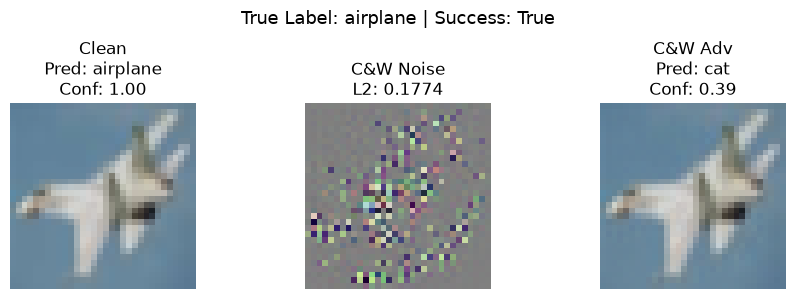

In [269]:
show_cw_example(
    model,
    test_loader,
    CW_C,
    CW_KAPPA,
    CW_STEPS,
    CW_LR,
    CIFAR10_CLASSES,
    device,
    idx=10
)